In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = "/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet"

TRAIN_CSV = os.path.join(
    DATASET_PATH,
    "train_classes.csv"
)

TRAIN_IMAGES_DIR = os.path.join(
    DATASET_PATH,
    "train-jpg"
)

OUTPUT_DIR = "/kaggle/working/outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Dataset Path:")
print(DATASET_PATH)

Dataset Path:
/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet


In [2]:
df = pd.read_csv(TRAIN_CSV)

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)

print(df.head())

DATASET LOADED SUCCESSFULLY
  image_name                                       tags
0    train_0                               haze primary
1    train_1            agriculture clear primary water
2    train_2                              clear primary
3    train_3                              clear primary
4    train_4  agriculture clear habitation primary road


In [3]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40479 entries, 0 to 40478
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  40479 non-null  object
 1   tags        40479 non-null  object
dtypes: object(2)
memory usage: 632.6+ KB


In [4]:
print("="*70)
print("DATASET SHAPE")
print("="*70)

print(df.shape)

DATASET SHAPE
(40479, 2)


In [5]:
all_tags = []

for tag_list in df["tags"]:
    all_tags.extend(tag_list.split())

tag_counts = pd.Series(all_tags).value_counts()

tag_counts.head(20)

primary              37513
clear                28431
agriculture          12315
road                  8071
water                 7411
partly_cloudy         7261
cultivation           4547
habitation            3660
haze                  2697
cloudy                2089
bare_ground            862
selective_logging      340
artisinal_mine         339
blooming               332
slash_burn             209
blow_down              101
conventional_mine      100
Name: count, dtype: int64

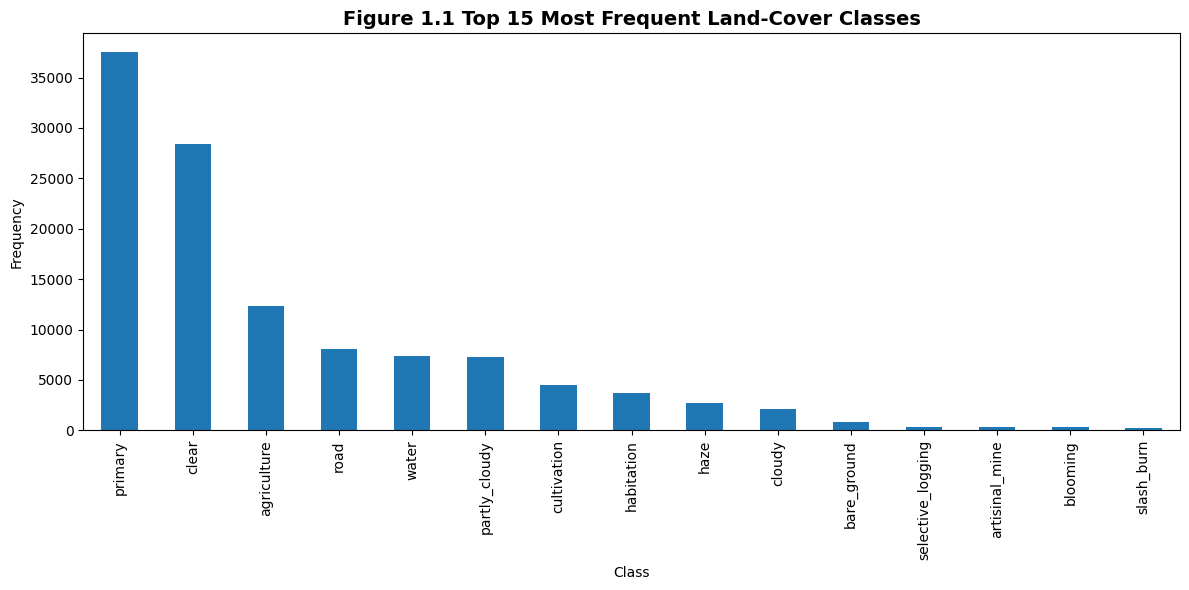

In [6]:
plt.figure(figsize=(12,6))

tag_counts.head(15).plot(
    kind="bar"
)

plt.title(
    "Figure 1.1 Top 15 Most Frequent Land-Cover Classes",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Class")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "class_distribution.pdf"
    )
)

plt.show()

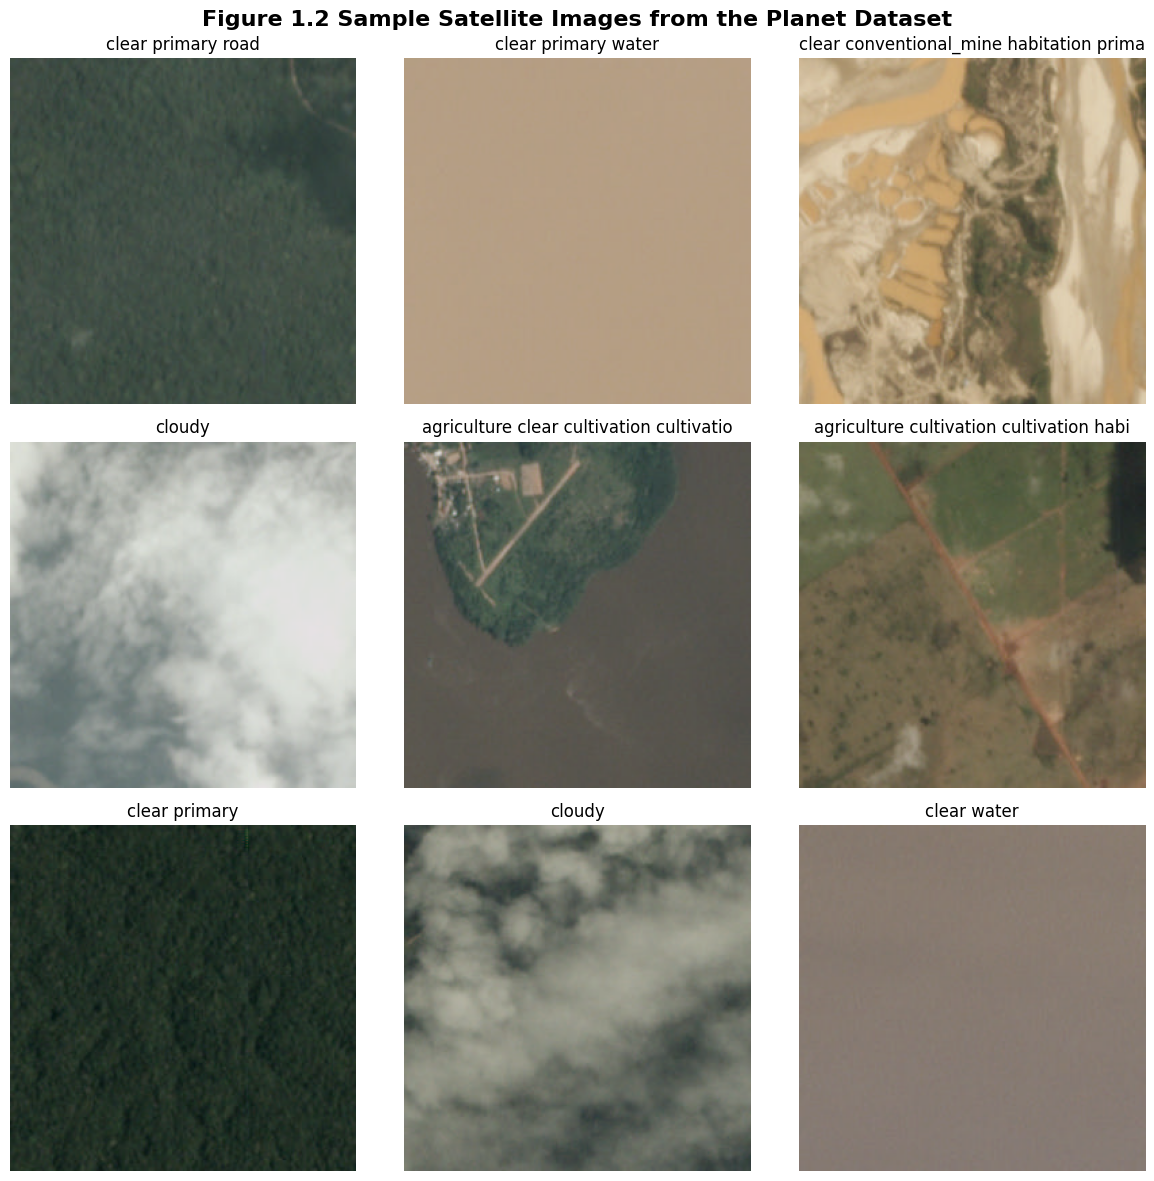

In [7]:
sample_images = df.sample(
    9,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_images.iterrows()
):

    image_path = os.path.join(
        TRAIN_IMAGES_DIR,
        row["image_name"] + ".jpg"
    )

    image = Image.open(
        image_path
    )

    ax.imshow(image)

    ax.set_title(
        row["tags"][:40]
    )

    ax.axis("off")

plt.suptitle(
    "Figure 1.2 Sample Satellite Images from the Planet Dataset",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "sample_images.pdf"
    )
)

plt.show()

In [8]:
dataset_summary = pd.DataFrame({

    "Metric":[
        "Total Images",
        "Total Classes"
    ],

    "Value":[
        len(df),
        len(tag_counts)
    ]
})

dataset_summary

,Metric,Value
0,Total Images,40479
1,Total Classes,17


In [9]:
dataset_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "dataset_summary.csv"
    ),

    index=False
)

print("Dataset Summary Saved")

Dataset Summary Saved


In [10]:
print("="*70)
print("NOTEBOOK 1 COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Generated Outputs

class_distribution.pdf

sample_images.pdf

dataset_summary.csv
""")

NOTEBOOK 1 COMPLETED SUCCESSFULLY

Generated Outputs

class_distribution.pdf

sample_images.pdf

dataset_summary.csv

